In [8]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import xarray as xr
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import lognorm
import cartopy as crs
import cartopy.crs as ccrs
import glob
from cartopy.mpl.ticker import LatitudeFormatter,LongitudeFormatter

In [9]:
basecase = glob.glob(r"/home/chandras/mosaic-paper/sensitivityanalysis/mosaic-basecase/path/*.nc")
basecase.sort()


In [10]:
def daily_data(filename):
    ds = xr.open_dataset(filename[0])
    for i in range(1,12):
        temp = xr.open_dataset(filename[i])
        ds = xr.combine_by_coords([ds,temp])
    return(ds)
def path_vals(ds,varname,lats,lons):
    #ds_new = ds.interp(lat = lats, lon = lons, method = 'linear')
    for i in range(len(lons[:-4])):
        if i==0:
            path_vals = ds.sel(lat = lats[i],lon = lons[i],lev = 0,time = ds.time[i],method = 'nearest')
        else:
            temp = ds.sel(lat = lats[i],lon = lons[i],lev= 0,time = ds.time[i],method = 'nearest')
            path_vals = xr.combine_nested([path_vals,temp],concat_dim = 'time')
    return path_vals

In [13]:
cmap = mpl.colormaps.get_cmap('viridis')

# Pick N numbers from 0 to 1
gradient = np.linspace(0, 1, 12)
colors = [mpl.colors.to_hex(cmap(i)) for i in gradient]

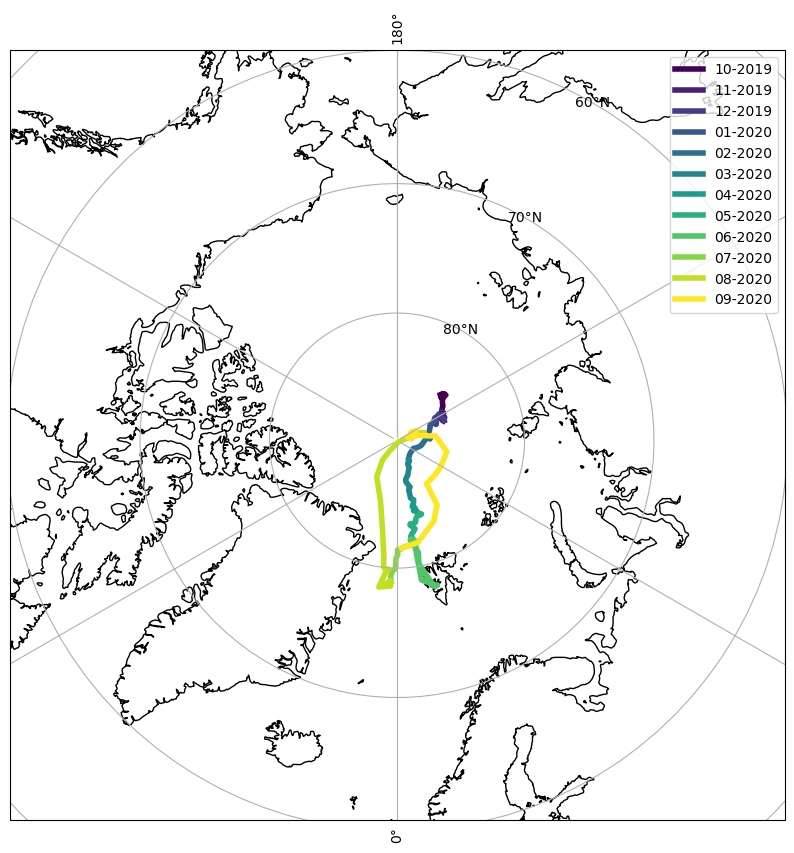

In [14]:
fig, axis = plt.subplots(1,1 ,figsize = (10,10),subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
labels = ['10-2019','11-2019','12-2019','01-2020','02-2020','03-2020','04-2020','05-2020','06-2020','07-2020','08-2020','09-2020']
for i in range(12):
    ds = xr.open_dataset(basecase[i])
    axis.plot(ds.lon,ds.lat,transform=ccrs.PlateCarree(),linewidth = 4,color = colors[i],label = labels[i])
    #print(color_val[i])
axis.set_extent([-180,180,90,60],ccrs.PlateCarree())
axis.coastlines()
axis.gridlines(draw_labels = True)
axis.get_xmajorticklabels()
plt.legend()
plt.savefig('../figures/mosaic-path.jpg',dpi = 300)